# COVID-19 Detection from Chest X-rays using CNN
## Mini Project

.

---
## Task 1: Data Loading and Exploration

In this section we will load the dataset, explore its structure, and visualize some sample images from each category.

In [1]:
# importing all the libraries we need
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16, ResNet50

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

import random

# setting seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.16.2


In [2]:
# extracting the dataset from zip file
import zipfile

zip_path = r'C:\Users\USSER\Downloads\archive(1).zip'
extract_path = r'C:\Users\USSER\Downloads\covid_dataset'

# extract only if not already done
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")

# setting the paths
base_dir = os.path.join(extract_path, 'Covid19-dataset')
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

print(f"\nTrain directory: {train_dir}")
print(f"Test directory: {test_dir}")

# lets see what classes we have
classes = os.listdir(train_dir)
print(f"\nClasses found: {classes}")

Dataset already extracted.

Train directory: C:\Users\USSER\Downloads\covid_dataset\Covid19-dataset\train
Test directory: C:\Users\USSER\Downloads\covid_dataset\Covid19-dataset\test

Classes found: ['Covid', 'Normal', 'Viral Pneumonia']


In [3]:
# now lets load all the images and resize them
IMG_SIZE = 128  # using 128x128 for faster training

def load_images(directory, img_size=IMG_SIZE):
    """Load images from directory and return images array with labels"""
    images = []
    labels = []
    
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # read the image
                img = cv2.imread(img_path)
                if img is None:
                    continue
                # convert BGR to RGB (opencv reads in BGR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # resize to fixed shape
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(class_name)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    return np.array(images), np.array(labels)

# loading training and test images
print("Loading training images...")
X_train_full, y_train_full = load_images(train_dir)
print(f"Training set: {X_train_full.shape[0]} images loaded")

print("\nLoading test images...")
X_test, y_test = load_images(test_dir)
print(f"Test set: {X_test.shape[0]} images loaded")

print(f"\nImage shape: {X_train_full[0].shape}")

Loading training images...
Training set: 251 images loaded

Loading test images...
Test set: 66 images loaded

Image shape: (128, 128, 3)


In [4]:
# lets check how many images per class
print("=" * 40)
print("Training set class distribution:")
print("=" * 40)
train_counts = Counter(y_train_full)
for cls, count in sorted(train_counts.items()):
    print(f"  {cls}: {count} images")

print(f"\nTotal training images: {len(y_train_full)}")

print("\n" + "=" * 40)
print("Test set class distribution:")
print("=" * 40)
test_counts = Counter(y_test)
for cls, count in sorted(test_counts.items()):
    print(f"  {cls}: {count} images")
    
print(f"\nTotal test images: {len(y_test)}")

Training set class distribution:
  Covid: 111 images
  Normal: 70 images
  Viral Pneumonia: 70 images

Total training images: 251

Test set class distribution:
  Covid: 26 images
  Normal: 20 images
  Viral Pneumonia: 20 images

Total test images: 66


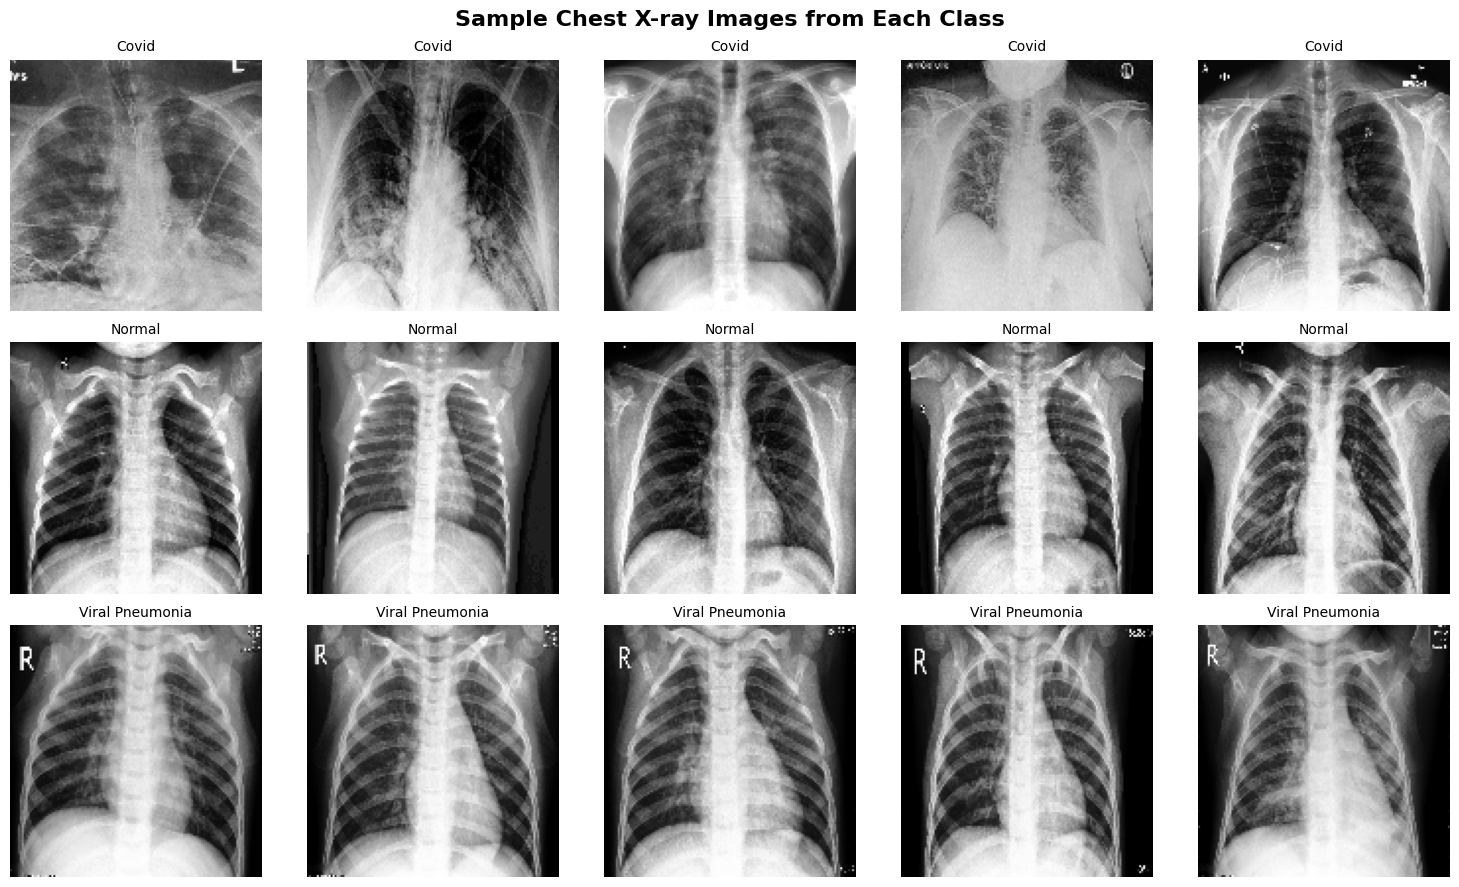

In [5]:
# display some sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Chest X-ray Images from Each Class', fontsize=16, fontweight='bold')

for i, class_name in enumerate(sorted(set(y_train_full))):
    # get indices for this class
    class_indices = np.where(y_train_full == class_name)[0]
    # pick 5 random samples
    sample_indices = np.random.choice(class_indices, 5, replace=False)
    
    for j, idx in enumerate(sample_indices):
        axes[i, j].imshow(X_train_full[idx])
        axes[i, j].set_title(class_name, fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

---
## Task 2: Data Preprocessing

Here we will normalize the pixel values, encode labels, and split data into train/validation/test sets.

In [6]:
# normalizing pixel values from 0-255 to 0-1
X_train_full_norm = X_train_full.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print(f"Before normalization - Min: {X_train_full.min()}, Max: {X_train_full.max()}")
print(f"After normalization  - Min: {X_train_full_norm.min():.4f}, Max: {X_train_full_norm.max():.4f}")

Before normalization - Min: 0, Max: 255
After normalization  - Min: 0.0000, Max: 1.0000


In [7]:
# encoding the labels
le = LabelEncoder()
y_train_full_encoded = le.fit_transform(y_train_full)
y_test_encoded = le.transform(y_test)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

# one-hot encoding for the models
num_classes = len(le.classes_)
y_train_full_onehot = to_categorical(y_train_full_encoded, num_classes)
y_test_onehot = to_categorical(y_test_encoded, num_classes)

print(f"\nOne-hot encoded shape: {y_train_full_onehot.shape}")
print(f"Example one-hot vector: {y_train_full_onehot[0]} -> {y_train_full[0]}")

Label mapping:
  Covid -> 0
  Normal -> 1
  Viral Pneumonia -> 2

One-hot encoded shape: (251, 3)
Example one-hot vector: [1. 0. 0.] -> Covid


In [8]:
# splitting into train and validation sets (80-20 split)
X_train, X_val, y_train, y_val, y_train_labels, y_val_labels = train_test_split(
    X_train_full_norm, y_train_full_onehot, y_train_full_encoded,
    test_size=0.2, random_state=42, stratify=y_train_full_encoded
)

print(f"Training set:   {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set:       {X_test_norm.shape[0]} images")
print(f"\nTraining image shape: {X_train.shape[1:]}")

Training set:   200 images
Validation set: 51 images
Test set:       66 images

Training image shape: (128, 128, 3)


---
## Task 3: Exploratory Data Analysis (EDA)

Let us visualize the class distributions and look for patterns in the data.

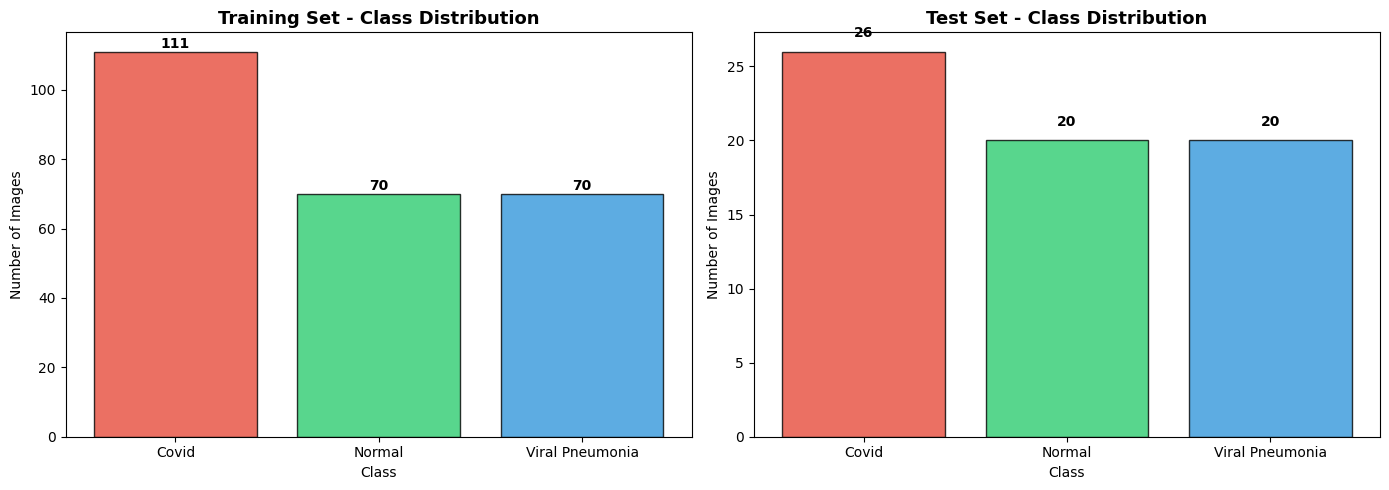

Observation: The dataset is slightly imbalanced - Covid class has more images
compared to Normal and Viral Pneumonia classes.


In [9]:
# class distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# training set distribution
train_classes = sorted(train_counts.keys())
train_values = [train_counts[c] for c in train_classes]
colors = ['#e74c3c', '#2ecc71', '#3498db']

axes[0].bar(train_classes, train_values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(train_values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# test set distribution
test_classes = sorted(test_counts.keys())
test_values = [test_counts[c] for c in test_classes]

axes[1].bar(test_classes, test_values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Test Set - Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(test_values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Observation: The dataset is slightly imbalanced - Covid class has more images")
print("compared to Normal and Viral Pneumonia classes.")

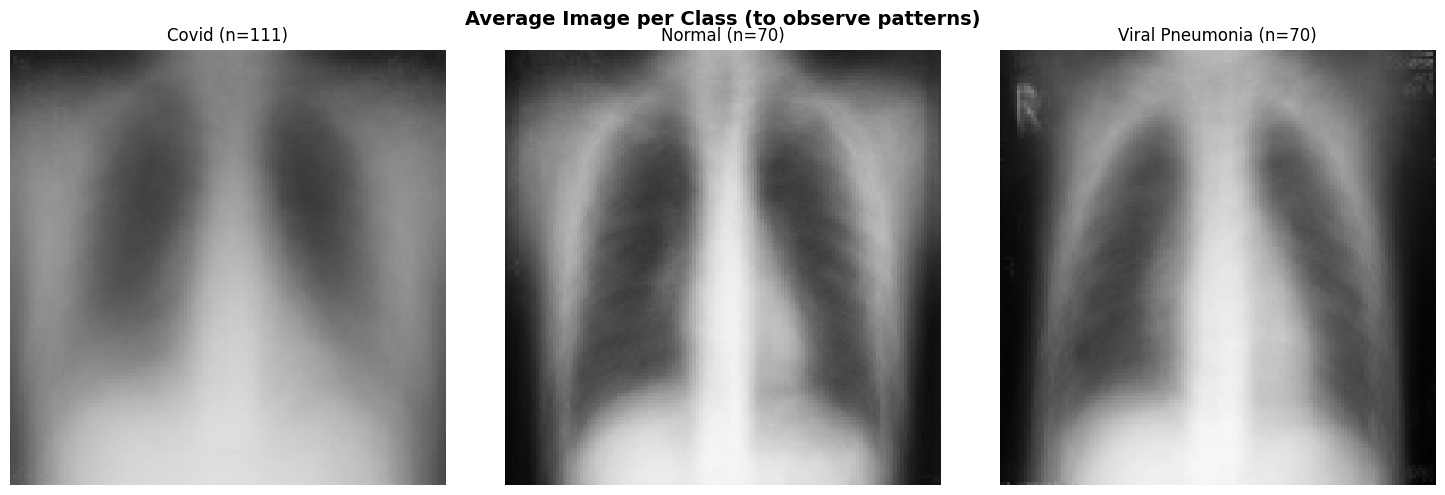


Observation: We can see subtle differences in the average images.
Covid cases tend to show more opacity/haziness in lung regions.


In [10]:
# lets look at the average image for each class to see patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Average Image per Class (to observe patterns)', fontsize=14, fontweight='bold')

for i, class_name in enumerate(sorted(set(y_train_full))):
    class_indices = np.where(y_train_full == class_name)[0]
    avg_img = np.mean(X_train_full[class_indices].astype('float32') / 255.0, axis=0)
    axes[i].imshow(avg_img)
    axes[i].set_title(f'{class_name} (n={len(class_indices)})', fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\nObservation: We can see subtle differences in the average images.")
print("Covid cases tend to show more opacity/haziness in lung regions.")

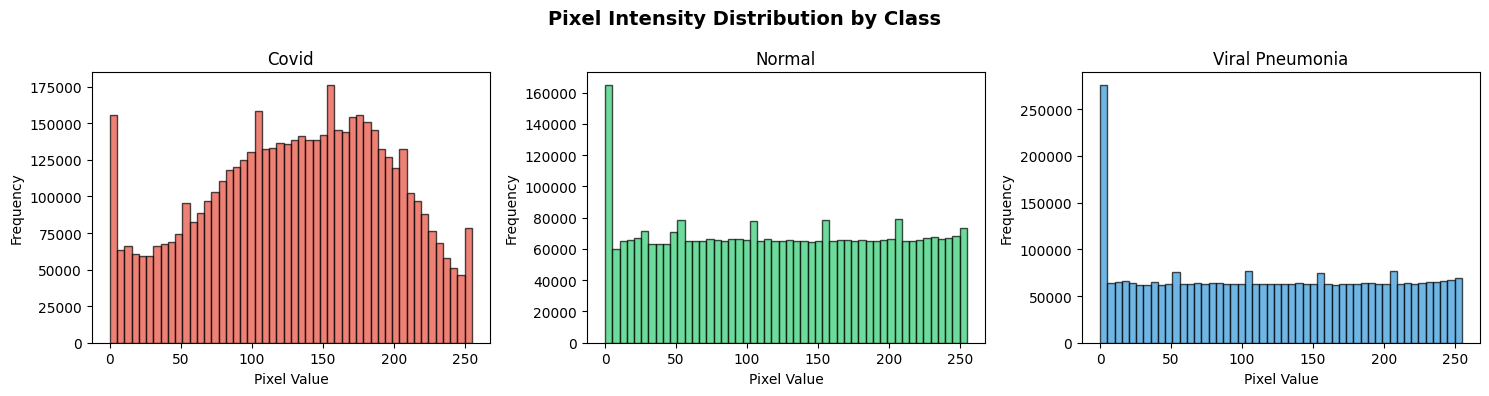

Observation: The pixel intensity distributions show some differences between classes.
This suggests that CNN models should be able to learn discriminative features.


In [11]:
# pixel intensity distribution for each class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Pixel Intensity Distribution by Class', fontsize=14, fontweight='bold')

for i, class_name in enumerate(sorted(set(y_train_full))):
    class_indices = np.where(y_train_full == class_name)[0]
    pixel_values = X_train_full[class_indices].flatten()
    axes[i].hist(pixel_values, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(class_name, fontsize=12)
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Observation: The pixel intensity distributions show some differences between classes.")
print("This suggests that CNN models should be able to learn discriminative features.")

---
## Task 4: CNN Model Building

We will build and train three different models:
1. **Model 1**: Basic CNN from scratch
2. **Model 2**: Transfer Learning with VGG16
3. **Model 3**: Transfer Learning + Data Augmentation

### Model 1: Basic CNN
A simple CNN with Conv2D, MaxPooling, and Dense layers.

In [12]:
# building basic cnn model
def build_basic_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    model = Sequential([
        # first conv block
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # second conv block
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # third conv block
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # flatten and dense layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model1 = build_basic_cnn()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,550,211 (24.99 MB)

 Trainable params: 6,549,763 (24.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# setting up callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=1e-6, verbose=1)

# training model 1
print("Training Model 1: Basic CNN")
print("=" * 50)

history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nModel 1 training complete!")

Training Model 1: Basic CNN
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 489ms/step - accuracy: 0.6750 - loss: 5.3176 - val_accuracy: 0.4510 - val_loss: 1.6005 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step - accuracy: 0.7950 - loss: 3.0741 - val_accuracy: 0.4510 - val_loss: 5.7681 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 423ms/step - accuracy: 0.8250 - loss: 2.2183 - val_accuracy: 0.4510 - val_loss: 15.2917 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - accuracy: 0.8650 - loss: 1.8125 - val_accuracy: 0.4510 - val_loss: 27.7080 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - accuracy: 0.8950 - loss: 1.3173 - val_accuracy: 0.4510 - val_loss: 31.8509 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8900 - loss: 1.1252
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - ac

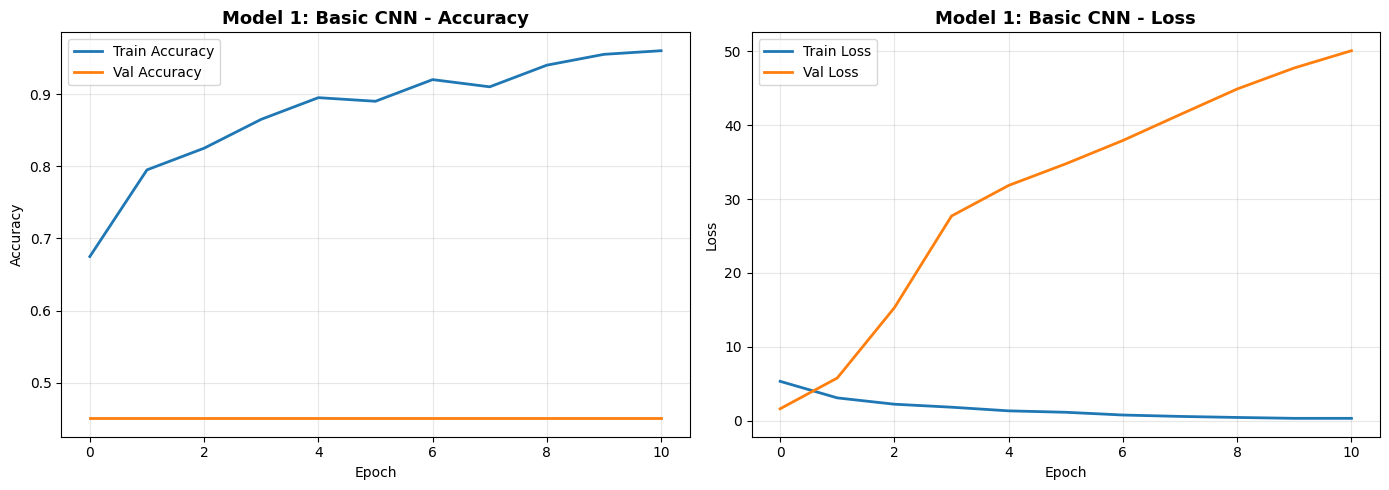

In [14]:
# plotting training history for model 1
def plot_training_history(history, model_name):
    """Plot accuracy and loss curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # accuracy plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{model_name} - Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # loss plot
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{model_name} - Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history1, 'Model 1: Basic CNN')

### Model 2: Transfer Learning with VGG16
Using a pre-trained VGG16 model and fine-tuning the last few layers on our dataset.

In [15]:
# building VGG16 transfer learning model
def build_vgg16_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    # load pretrained VGG16 without top layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # freeze most layers, only train last 4 layers
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    
    # add our own classification head
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model2 = build_vgg16_model()

# print trainable vs non-trainable params
trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model2.trainable_weights])
non_trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model2.non_trainable_weights])
print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters: {non_trainable_count:,}")
print(f"Total parameters: {trainable_count + non_trainable_count:,}")

Trainable parameters: 7,244,035
Non-trainable parameters: 7,635,264
Total parameters: 14,879,299


In [16]:
# training model 2
early_stop2 = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)
reduce_lr2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                               patience=5, min_lr=1e-7, verbose=1)

print("Training Model 2: VGG16 Transfer Learning")
print("=" * 50)

history2 = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

print("\nModel 2 training complete!")

Training Model 2: VGG16 Transfer Learning
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.4900 - loss: 1.0214 - val_accuracy: 0.8824 - val_loss: 0.6301 - learning_rate: 1.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7500 - loss: 0.6200 - val_accuracy: 0.9412 - val_loss: 0.3272 - learning_rate: 1.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8600 - loss: 0.3972 - val_accuracy: 0.9608 - val_loss: 0.1893 - learning_rate: 1.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9300 - loss: 0.2419 - val_accuracy: 0.8627 - val_loss: 0.2750 - learning_rate: 1.0000e-04
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9350 - loss: 0.2028 - val_accuracy: 0.8824 - val_loss: 0.3130 - learning_rate: 1.0000e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9550 - loss: 0.1350 - val_accuracy: 0.9412 - val_loss: 0.1604 - learning_rate: 1.0000e-04
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━

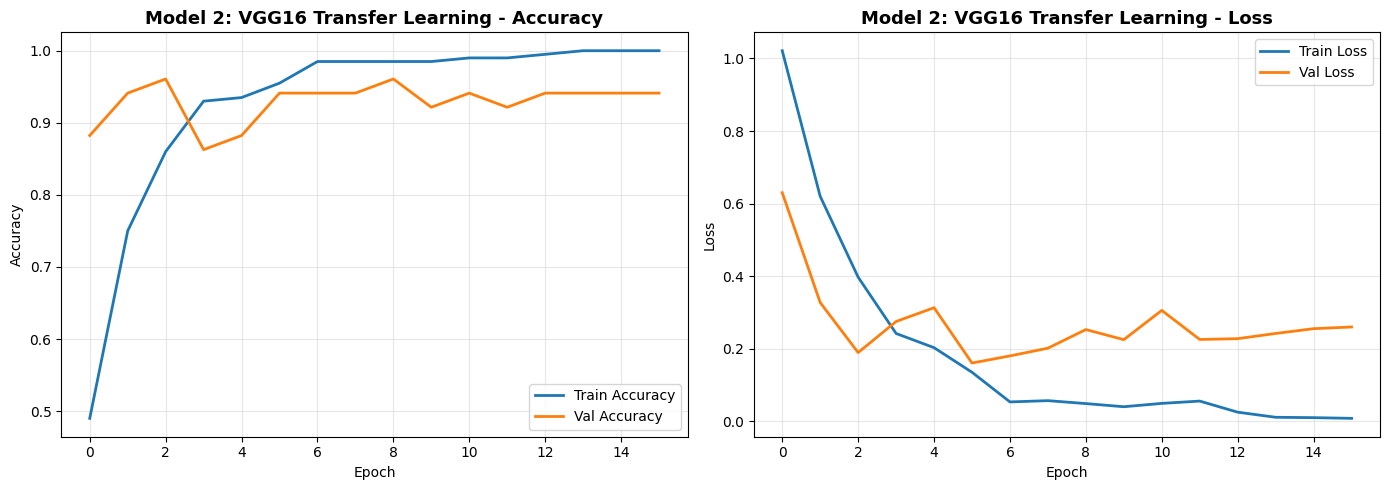

In [17]:
plot_training_history(history2, 'Model 2: VGG16 Transfer Learning')

### Model 3: Transfer Learning + Data Augmentation
Using VGG16 with data augmentation to improve generalization and handle class imbalance.

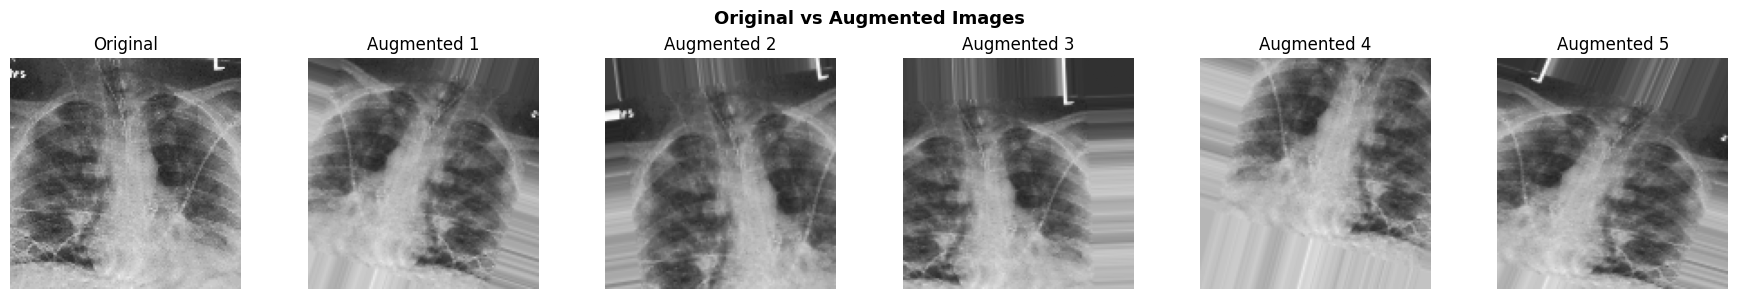

In [18]:
# setting up data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# lets see what augmented images look like
sample_img = X_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle('Original vs Augmented Images', fontsize=13, fontweight='bold')

axes[0].imshow(sample_img[0])
axes[0].set_title('Original')
axes[0].axis('off')

aug_iter = train_datagen.flow(sample_img, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# building model 3 - VGG16 with data augmentation
def build_vgg16_augmented(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # freeze all except last 4 layers
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model3 = build_vgg16_augmented()

# training with augmentation
early_stop3 = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)
reduce_lr3 = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                               patience=5, min_lr=1e-7, verbose=1)

print("Training Model 3: VGG16 + Data Augmentation")
print("=" * 50)

# using flow for augmented training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=16)

history3 = model3.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 16,
    epochs=40,
    validation_data=(X_val, y_val),
    callbacks=[early_stop3, reduce_lr3],
    verbose=1
)

print("\nModel 3 training complete!")

Training Model 3: VGG16 + Data Augmentation
Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5217 - loss: 1.1190 - val_accuracy: 0.4314 - val_loss: 0.9767 - learning_rate: 1.0000e-04
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 461ms/step - accuracy: 0.7500 - loss: 0.8042 - val_accuracy: 0.4314 - val_loss: 0.9565 - learning_rate: 1.0000e-04
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7240 - loss: 0.7187 - val_accuracy: 0.7255 - val_loss: 0.8373 - learning_rate: 1.0000e-04
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.5000 - loss: 0.8908 - val_accuracy: 0.7255 - val_loss: 0.8354 - learning_rate: 1.0000e-04
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.7337 - loss: 0.6382 - val_accuracy: 0.6667 - val_loss: 0.8121 - learning_rate: 1.0000e-04
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 699ms/step - accuracy: 0.8750 - loss: 0.5062 - val_accuracy: 0.6667 - val_loss: 0.8029 - learning_rate: 1.0000e-04
Epoch 7/40
12/12 ━━━━━━━━

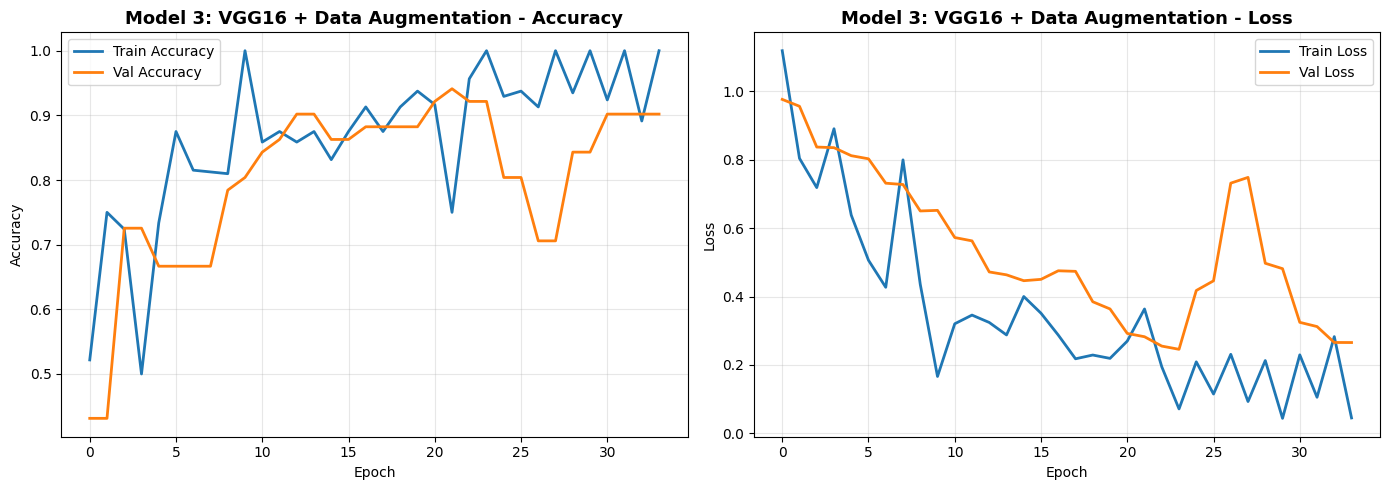

In [20]:
plot_training_history(history3, 'Model 3: VGG16 + Data Augmentation')

---
## Task 5: Model Evaluation

Evaluating all three models using accuracy, confusion matrix, classification report, and ROC-AUC score.

In [21]:
# function to evaluate a model completely
def evaluate_model(model, X_test, y_test_onehot, y_test_encoded, model_name, le):
    """Complete evaluation of a model"""
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}")
    
    # predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # accuracy
    test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    
    # classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))
    
    # confusion matrix
    cm = confusion_matrix(y_test_encoded, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # ROC-AUC score (one-vs-rest for multiclass)
    try:
        roc_auc = roc_auc_score(y_test_onehot, y_pred_proba,
                                multi_class='ovr', average='weighted')
        print(f"ROC-AUC Score (weighted): {roc_auc:.4f}")
    except Exception as e:
        roc_auc = None
        print(f"Could not compute ROC-AUC: {e}")
    
    # number of trainable parameters
    trainable_params = np.sum([tf.keras.backend.count_params(w)
                               for w in model.trainable_weights])
    total_params = model.count_params()
    print(f"\nTrainable Parameters: {trainable_params:,}")
    print(f"Total Parameters: {total_params:,}")
    
    return test_acc, test_loss, roc_auc, trainable_params, total_params


Evaluation: Model 1: Basic CNN

Test Accuracy: 0.3939
Test Loss: 1.7516

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



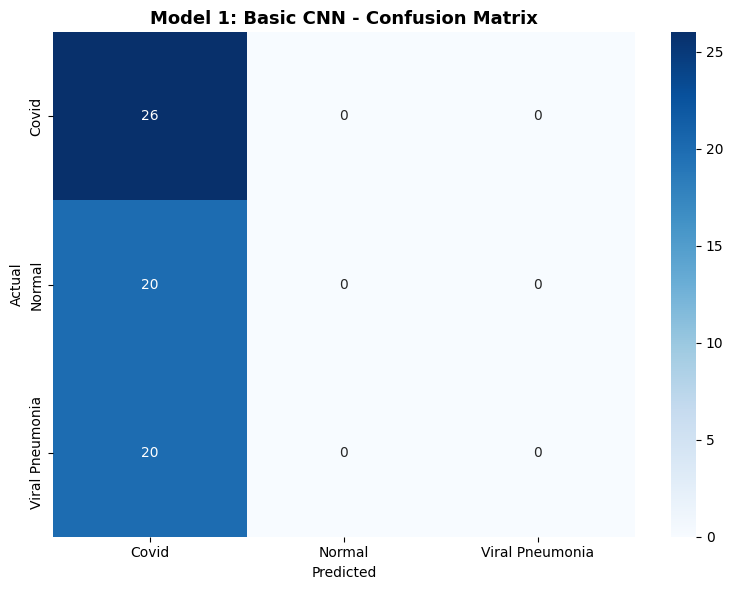

ROC-AUC Score (weighted): 0.8248

Trainable Parameters: 6,549,763
Total Parameters: 6,550,211


In [22]:
# evaluate all 3 models
results = {}

acc1, loss1, auc1, tp1, total1 = evaluate_model(
    model1, X_test_norm, y_test_onehot, y_test_encoded, 'Model 1: Basic CNN', le)
results['Basic CNN'] = {
    'accuracy': acc1, 'loss': loss1, 'roc_auc': auc1,
    'trainable_params': tp1, 'total_params': total1
}


Evaluation: Model 2: VGG16

Test Accuracy: 0.9394
Test Loss: 0.1866

Classification Report:
                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.80      0.89        20
Viral Pneumonia       0.83      1.00      0.91        20

       accuracy                           0.94        66
      macro avg       0.94      0.93      0.93        66
   weighted avg       0.95      0.94      0.94        66



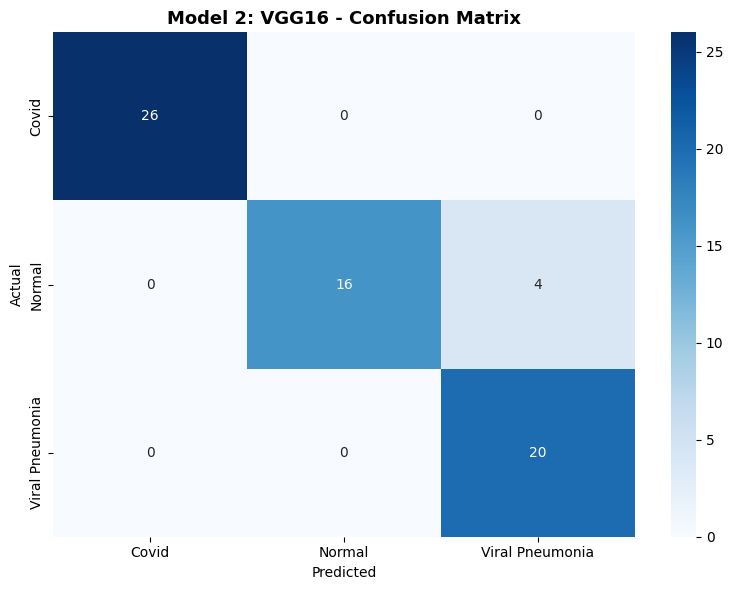

ROC-AUC Score (weighted): 0.9964

Trainable Parameters: 7,244,035
Total Parameters: 14,879,299


In [23]:
acc2, loss2, auc2, tp2, total2 = evaluate_model(
    model2, X_test_norm, y_test_onehot, y_test_encoded, 'Model 2: VGG16', le)
results['VGG16'] = {
    'accuracy': acc2, 'loss': loss2, 'roc_auc': auc2,
    'trainable_params': tp2, 'total_params': total2
}


Evaluation: Model 3: VGG16 + Augmentation

Test Accuracy: 0.9848
Test Loss: 0.1761

Classification Report:
                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.95      1.00      0.98        20
Viral Pneumonia       1.00      0.95      0.97        20

       accuracy                           0.98        66
      macro avg       0.98      0.98      0.98        66
   weighted avg       0.99      0.98      0.98        66



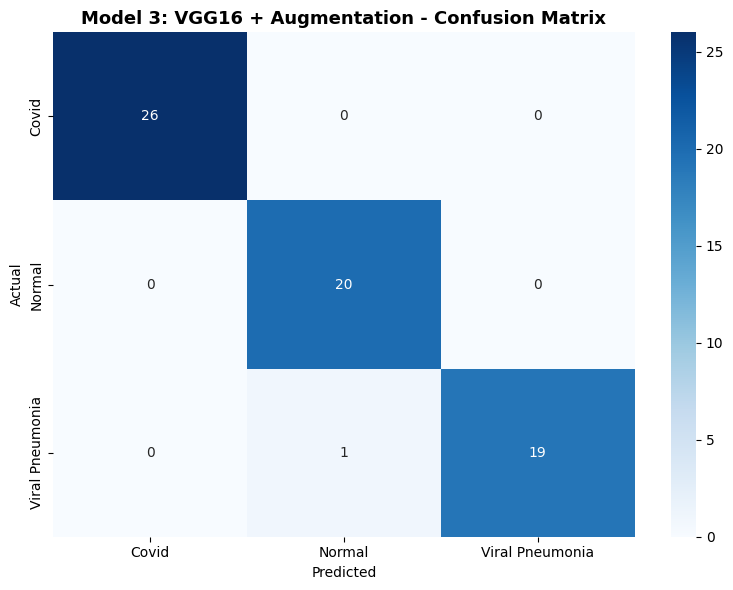

ROC-AUC Score (weighted): 0.9984

Trainable Parameters: 7,244,547
Total Parameters: 14,880,323


In [24]:
acc3, loss3, auc3, tp3, total3 = evaluate_model(
    model3, X_test_norm, y_test_onehot, y_test_encoded,
    'Model 3: VGG16 + Augmentation', le)
results['VGG16 + Augmentation'] = {
    'accuracy': acc3, 'loss': loss3, 'roc_auc': auc3,
    'trainable_params': tp3, 'total_params': total3
}

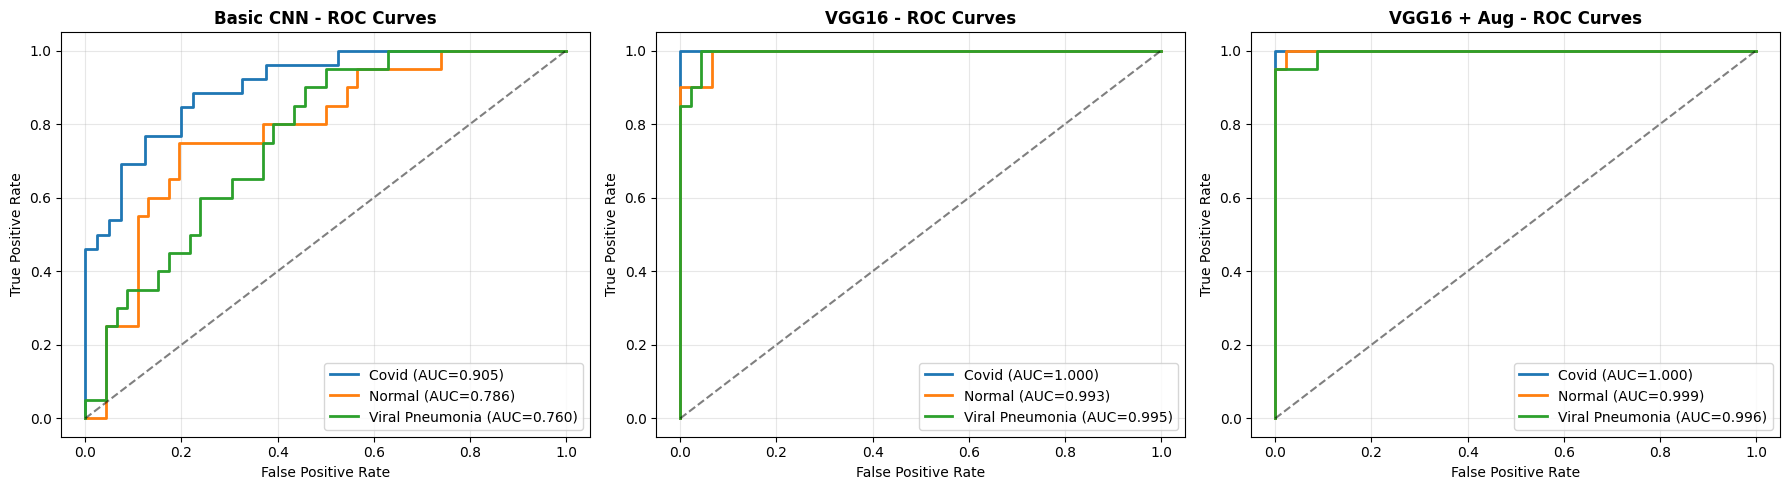

In [25]:
# ROC curves for all models (per class)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_list = [('Basic CNN', model1), ('VGG16', model2), ('VGG16 + Aug', model3)]

for idx, (name, model) in enumerate(model_list):
    y_pred_proba = model.predict(X_test_norm, verbose=0)
    
    for i, class_name in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, linewidth=2,
                       label=f'{class_name} (AUC={roc_auc_val:.3f})')
    
    axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[idx].set_title(f'{name} - ROC Curves', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# checking overfitting - comparing train vs val accuracy/loss
print("Overfitting Analysis")
print("=" * 60)

histories = [('Basic CNN', history1), ('VGG16', history2), ('VGG16 + Aug', history3)]

for name, hist in histories:
    final_train_acc = hist.history['accuracy'][-1]
    final_val_acc = hist.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    
    print(f"\n{name}:")
    print(f"  Final Train Accuracy: {final_train_acc:.4f}")
    print(f"  Final Val Accuracy:   {final_val_acc:.4f}")
    print(f"  Gap (overfitting):    {gap:.4f}")
    if gap > 0.15:
        print(f"  --> Signs of overfitting (gap > 0.15)")
    else:
        print(f"  --> Looks okay, not heavily overfitting")

Overfitting Analysis

Basic CNN:
  Final Train Accuracy: 0.9600
  Final Val Accuracy:   0.4510
  Gap (overfitting):    0.5090
  --> Signs of overfitting (gap > 0.15)

VGG16:
  Final Train Accuracy: 1.0000
  Final Val Accuracy:   0.9412
  Gap (overfitting):    0.0588
  --> Looks okay, not heavily overfitting

VGG16 + Aug:
  Final Train Accuracy: 1.0000
  Final Val Accuracy:   0.9020
  Gap (overfitting):    0.0980
  --> Looks okay, not heavily overfitting


---
## Task 6: Handling Class Imbalance

Analyzing the class imbalance and applying techniques like class weights and data augmentation.

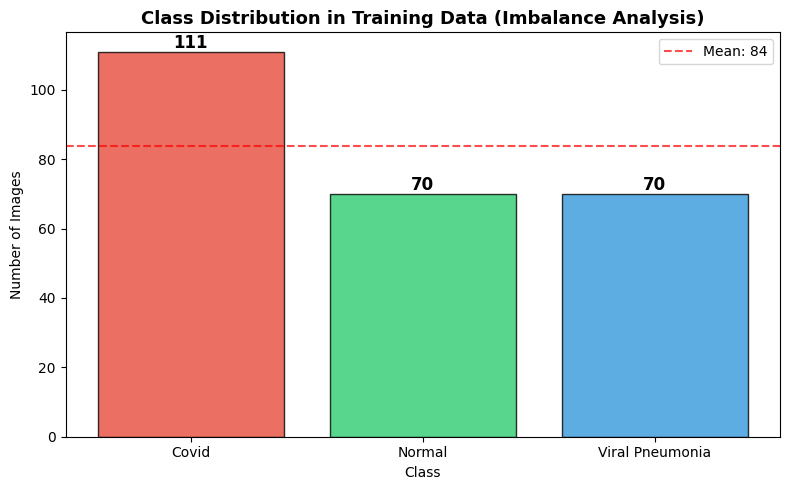


Class distribution: {'Covid': 111, 'Normal': 70, 'Viral Pneumonia': 70}
Imbalance ratio (max/min): 1.59


In [27]:
# visualize the class imbalance
fig, ax = plt.subplots(figsize=(8, 5))

class_names = sorted(set(y_train_full))
class_counts = [Counter(y_train_full)[c] for c in class_names]

bars = ax.bar(class_names, class_counts, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Class Distribution in Training Data (Imbalance Analysis)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', fontweight='bold', fontsize=12)

# add a horizontal line at the mean
mean_count = np.mean(class_counts)
ax.axhline(y=mean_count, color='red', linestyle='--', alpha=0.7,
           label=f'Mean: {mean_count:.0f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nClass distribution: {dict(zip(class_names, class_counts))}")
print(f"Imbalance ratio (max/min): {max(class_counts)/min(class_counts):.2f}")

In [28]:
# computing class weights to handle imbalance
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train_labels),
                                     y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))

print("Computed class weights:")
for idx, weight in class_weight_dict.items():
    print(f"  Class {idx} ({le.classes_[idx]}): {weight:.4f}")

print("\nHigher weight means the model will pay more attention to that class.")
print("This helps compensate for having fewer samples.")

Computed class weights:
  Class 0 (Covid): 0.7576
  Class 1 (Normal): 1.1905
  Class 2 (Viral Pneumonia): 1.1905

Higher weight means the model will pay more attention to that class.
This helps compensate for having fewer samples.


Retraining Basic CNN with class weights...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 455ms/step - accuracy: 0.6200 - loss: 6.8864 - val_accuracy: 0.6078 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 435ms/step - accuracy: 0.8100 - loss: 3.2148 - val_accuracy: 0.4510 - val_loss: 5.5589 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 428ms/step - accuracy: 0.8000 - loss: 2.4004 - val_accuracy: 0.4510 - val_loss: 13.5698 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.8650 - loss: 2.4963 - val_accuracy: 0.4510 - val_loss: 15.5189 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 370ms/step - accuracy: 0.8900 - loss: 1.6313 - val_accuracy: 0.4510 - val_loss: 19.6573 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8600 - loss: 1.2496
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s

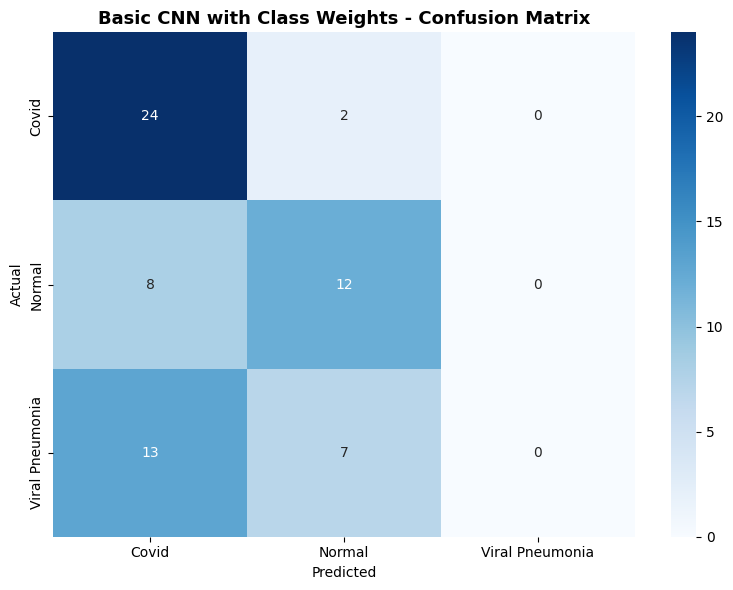

ROC-AUC Score (weighted): 0.6777

Trainable Parameters: 6,549,763
Total Parameters: 6,550,211

Comparison:
  Basic CNN (original):      0.3939
  Basic CNN (class weights): 0.5455


In [29]:
# retraining Model 1 (Basic CNN) with class weights to see improvement
print("Retraining Basic CNN with class weights...")
print("=" * 50)

model1_balanced = build_basic_cnn()

early_stop_b = EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True, verbose=1)
reduce_lr_b = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                patience=5, min_lr=1e-6, verbose=1)

history1_balanced = model1_balanced.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop_b, reduce_lr_b],
    verbose=1
)

# evaluate
acc_b, loss_b, auc_b, _, _ = evaluate_model(
    model1_balanced, X_test_norm, y_test_onehot, y_test_encoded, 
    'Basic CNN with Class Weights', le
)

print(f"\nComparison:")
print(f"  Basic CNN (original):      {results['Basic CNN']['accuracy']:.4f}")
print(f"  Basic CNN (class weights): {acc_b:.4f}")

---
## Task 7: Model Tuning

Using early stopping (already applied above), hyperparameter tuning, and Keras Tuner for optimization.

Hyperparameter Tuning - Testing different configurations
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6300 - loss: 1.4446 - val_accuracy: 0.4510 - val_loss: 1.0618 - learning_rate: 1.0000e-04
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8550 - loss: 0.5092 - val_accuracy: 0.4510 - val_loss: 1.0858 - learning_rate: 1.0000e-04
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 993ms/step - accuracy: 0.8950 - loss: 0.5554 - val_accuracy: 0.4510 - val_loss: 1.2820 - learning_rate: 1.0000e-04
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9500 - loss: 0.1901 - val_accuracy: 0.4510 - val_loss: 1.6237 - learning_rate: 1.0000e-04
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8950 - loss: 0.2741 - val_accuracy: 0.4510 - val_loss: 1.9633 - learning_rate: 1.0000e-04
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9200 - loss: 0.2787
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
13/13 ━━━━

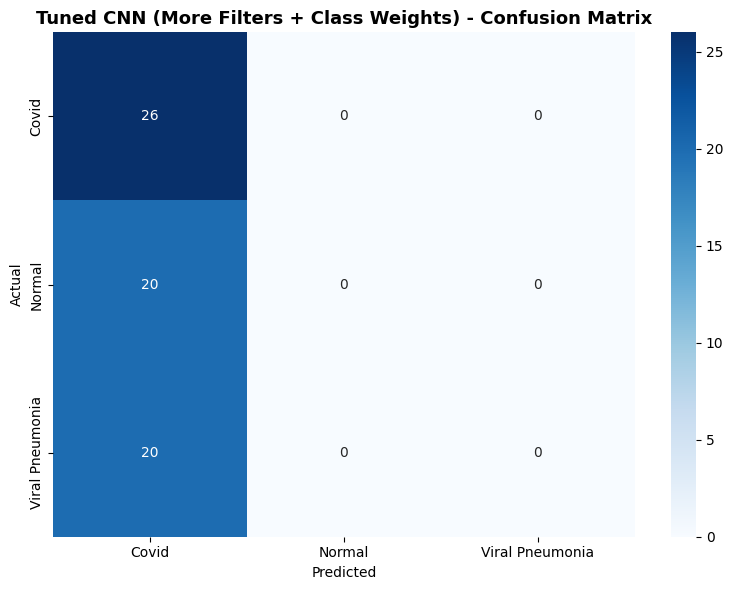

ROC-AUC Score (weighted): 0.8687

Trainable Parameters: 5,813,507
Total Parameters: 5,814,915


In [30]:
# we already used early stopping above, lets do manual hyperparameter tuning
# trying a deeper CNN with more filters

print("Hyperparameter Tuning - Testing different configurations")
print("=" * 60)

# config: more filters + deeper architecture
def build_tuned_cnn_v1():
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_tuned = build_tuned_cnn_v1()

early_stop_t = EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True, verbose=1)
reduce_lr_t = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                patience=5, min_lr=1e-7, verbose=1)

history_tuned = model_tuned.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop_t, reduce_lr_t],
    verbose=1
)

acc_t, loss_t, auc_t, tp_t, total_t = evaluate_model(
    model_tuned, X_test_norm, y_test_onehot, y_test_encoded,
    'Tuned CNN (More Filters + Class Weights)', le
)

Trial 5 Complete [00h 01m 41s]
val_accuracy: 0.8235294222831726

Best val_accuracy So Far: 0.9215686321258545
Total elapsed time: 00h 20m 40s

Best Hyperparameters found:
  Num extra conv blocks: 1
  Dense units: 128
  Dropout rate: 0.2
  Learning rate: 0.0005

Evaluation: Keras Tuner Best Model

Test Accuracy: 0.8636
Test Loss: 0.4673

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.96      0.88      0.92        26
         Normal       0.71      1.00      0.83        20
Viral Pneumonia       1.00      0.70      0.82        20

       accuracy                           0.86        66
      macro avg       0.89      0.86      0.86        66
   weighted avg       0.90      0.86      0.86        66



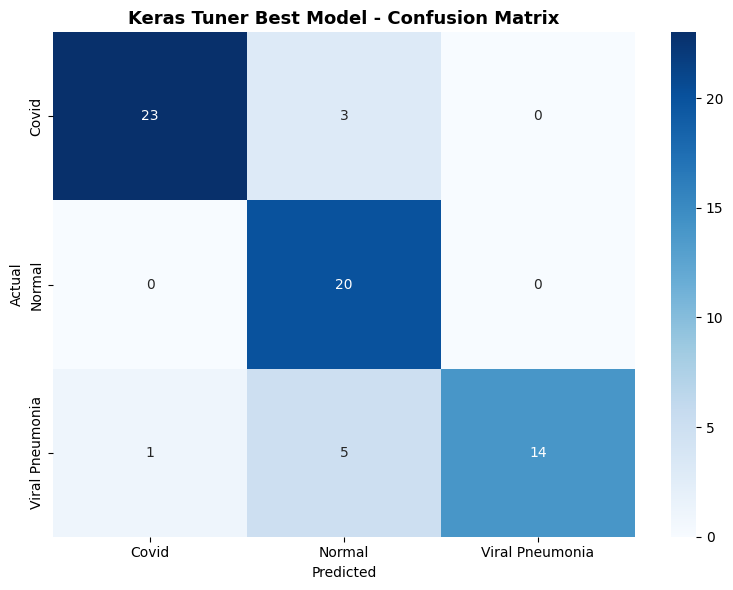

ROC-AUC Score (weighted): 0.9638

Trainable Parameters: 32,516,483
Total Parameters: 32,516,611


In [31]:
# Keras Tuner for deeper optimization
# Note: install keras-tuner if not already installed: pip install keras-tuner
try:
    import keras_tuner as kt
    
    def build_model_for_tuner(hp):
        model = Sequential()
        
        # first conv layer always needs input_shape
        first_filters = hp.Choice('filters_0', values=[32, 64, 128])
        model.add(Conv2D(first_filters, (3, 3), activation='relu',
                         input_shape=(IMG_SIZE, IMG_SIZE, 3)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D((2, 2)))
        
        # additional conv blocks
        for i in range(1, hp.Int('num_extra_conv_blocks', 1, 3)):
            filters = hp.Choice(f'filters_{i}', values=[64, 128, 256])
            model.add(Conv2D(filters, (3, 3), activation='relu'))
            model.add(BatchNormalization())
            model.add(MaxPooling2D((2, 2)))
        
        model.add(Flatten())
        
        # tune dense layer size
        dense_units = hp.Choice('dense_units', values=[128, 256, 512])
        model.add(Dense(dense_units, activation='relu'))
        
        # tune dropout rate
        dropout_rate = hp.Float('dropout_rate', 0.2, 0.6, step=0.1)
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(num_classes, activation='softmax'))
        
        # tune learning rate
        lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    tuner = kt.RandomSearch(
        build_model_for_tuner,
        objective='val_accuracy',
        max_trials=5,
        executions_per_trial=1,
        directory='tuner_results',
        project_name='covid_xray',
        overwrite=True
    )
    
    tuner.search(
        X_train, y_train,
        epochs=20,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                 restore_best_weights=True)],
        verbose=1
    )
    
    # get best hyperparameters
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\nBest Hyperparameters found:")
    print(f"  Num extra conv blocks: {best_hp.get('num_extra_conv_blocks')}")
    print(f"  Dense units: {best_hp.get('dense_units')}")
    print(f"  Dropout rate: {best_hp.get('dropout_rate')}")
    print(f"  Learning rate: {best_hp.get('learning_rate')}")
    
    # get best model and evaluate
    best_model = tuner.get_best_models(1)[0]
    acc_kt, _, auc_kt, _, _ = evaluate_model(
        best_model, X_test_norm, y_test_onehot, y_test_encoded,
        'Keras Tuner Best Model', le
    )
    
except ImportError:
    print("keras-tuner is not installed. Install with: pip install keras-tuner")
    print("Skipping Keras Tuner optimization.")
    best_model = None
    acc_kt = None
    auc_kt = None

---
## Task 8: Model Comparison Table

Comparing all models side by side to pick the best one.

In [32]:
# creating comparison table
import pandas as pd

comparison_data = {
    'Model': [
        'Basic CNN',
        'VGG16 Transfer Learning',
        'VGG16 + Data Augmentation',
        'Basic CNN + Class Weights',
        'Tuned CNN + Class Weights'
    ],
    'Test Accuracy': [
        f"{results['Basic CNN']['accuracy']:.4f}",
        f"{results['VGG16']['accuracy']:.4f}",
        f"{results['VGG16 + Augmentation']['accuracy']:.4f}",
        f"{acc_b:.4f}",
        f"{acc_t:.4f}"
    ],
    'Test Loss': [
        f"{results['Basic CNN']['loss']:.4f}",
        f"{results['VGG16']['loss']:.4f}",
        f"{results['VGG16 + Augmentation']['loss']:.4f}",
        f"{loss_b:.4f}",
        f"{loss_t:.4f}"
    ],
    'ROC-AUC': [
        f"{results['Basic CNN']['roc_auc']:.4f}" if results['Basic CNN']['roc_auc'] else 'N/A',
        f"{results['VGG16']['roc_auc']:.4f}" if results['VGG16']['roc_auc'] else 'N/A',
        f"{results['VGG16 + Augmentation']['roc_auc']:.4f}" if results['VGG16 + Augmentation']['roc_auc'] else 'N/A',
        f"{auc_b:.4f}" if auc_b else 'N/A',
        f"{auc_t:.4f}" if auc_t else 'N/A'
    ],
    'Trainable Params': [
        f"{results['Basic CNN']['trainable_params']:,}",
        f"{results['VGG16']['trainable_params']:,}",
        f"{results['VGG16 + Augmentation']['trainable_params']:,}",
        f"{results['Basic CNN']['trainable_params']:,}",
        f"{tp_t:,}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 85)
print("MODEL COMPARISON TABLE")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)


MODEL COMPARISON TABLE
                    Model Test Accuracy Test Loss ROC-AUC Trainable Params
                Basic CNN        0.3939    1.7516  0.8248        6,549,763
  VGG16 Transfer Learning        0.9394    0.1866  0.9964        7,244,035
VGG16 + Data Augmentation        0.9848    0.1761  0.9984        7,244,547
Basic CNN + Class Weights        0.5455    1.0868  0.6777        6,549,763
Tuned CNN + Class Weights        0.3939    1.0745  0.8687        5,813,507


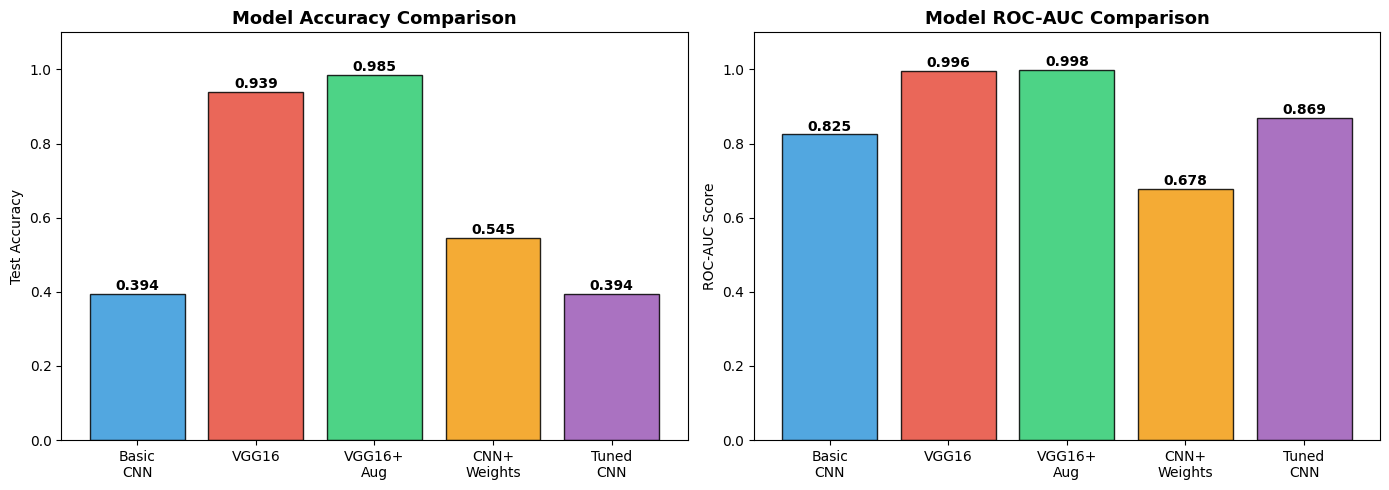

In [33]:
# visual comparison of all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['Basic\nCNN', 'VGG16', 'VGG16+\nAug', 'CNN+\nWeights', 'Tuned\nCNN']
accuracies = [results['Basic CNN']['accuracy'],
              results['VGG16']['accuracy'], 
              results['VGG16 + Augmentation']['accuracy'],
              acc_b, acc_t]

bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# accuracy comparison
bars = axes[0].bar(model_names, accuracies, color=bar_colors,
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0, 1.1)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontweight='bold')

# ROC-AUC comparison  
auc_values = [
    results['Basic CNN']['roc_auc'] or 0,
    results['VGG16']['roc_auc'] or 0,
    results['VGG16 + Augmentation']['roc_auc'] or 0,
    auc_b or 0,
    auc_t or 0
]

bars2 = axes[1].bar(model_names, auc_values, color=bar_colors,
                    edgecolor='black', alpha=0.85)
axes[1].set_title('Model ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
for bar, auc_val in zip(bars2, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{auc_val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Conclusion

In this project, we built and compared multiple CNN models for COVID-19 detection from chest X-ray images:

1. **Basic CNN** - A simple model built from scratch with 3 conv blocks
2. **VGG16 Transfer Learning** - Using pre-trained VGG16 with fine-tuning
3. **VGG16 + Data Augmentation** - VGG16 with augmented training data
4. **Basic CNN with Class Weights** - Addressing class imbalance
5. **Tuned CNN** - Deeper architecture with hyperparameter optimization

**Key Takeaways:**
- Transfer learning with VGG16 generally performs better than basic CNN because it uses pre-trained features from ImageNet
- Data augmentation helps the model generalize better especially when we have a small dataset like ours
- Class weights help improve performance on minority classes (Normal and Viral Pneumonia)
- Early stopping and learning rate reduction are important to prevent overfitting
- Using Keras Tuner allows us to systematically search for better hyperparameters



In [ ]:
import joblib
model3.save('best_covid_xray_model.h5')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']